In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [32]:
df = pd.read_csv('../data/housing.csv')
print("\n✓ Dataset cargado")

print("Shape:", df.shape)
print("\nHead:\n", df.head())
print("\nDescribe:\n", df.describe())


✓ Dataset cargado
Shape: (545, 13)

Head:
       price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  

Describe:
               price          area    bedroo

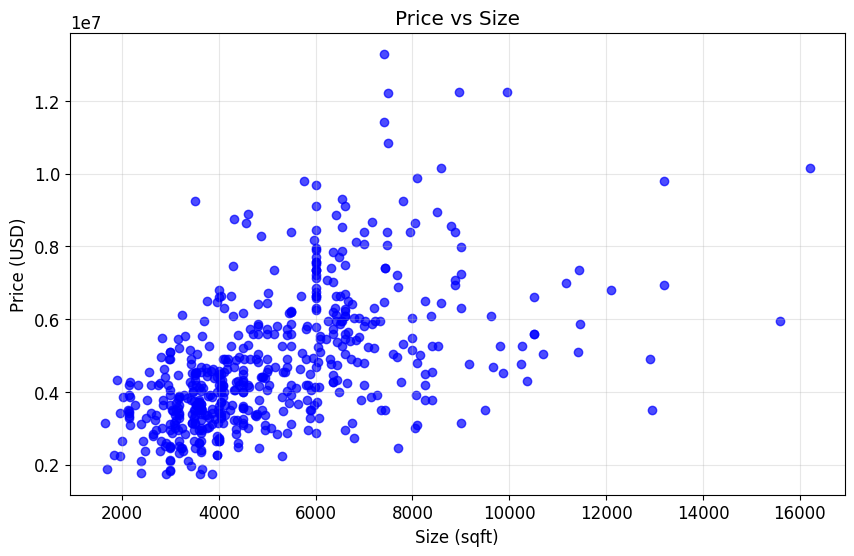

In [33]:
plt.scatter(df['area'], df['price'], c='blue', alpha=0.7)
plt.xlabel('Size (sqft)')
plt.ylabel('Price (USD)')
plt.title('Price vs Size')
plt.grid(True, alpha=0.3)
plt.show()

In [34]:
x_train = df['area'].values
y_train = df['price'].values

m = x_train.shape[0]  # Number of training examples
print("\n✓ Number of training examples (m):", m)
print("\n✓ x_train shape:", x_train.shape)
print("✓ y_train shape:", y_train.shape)


✓ Number of training examples (m): 545

✓ x_train shape: (545,)
✓ y_train shape: (545,)


In [35]:
def compute_cost(x, y, w, b):
    m = x.shape[0]
    cost = 0

    for i in range(m):
        f_wb = w * x[i] + b
        cost += (f_wb - y[i]) ** 2
    total_cost = 1 / (2 * m) * cost
    
    return total_cost

#Tests
w_test, b_test = 0, 0
print(f"Initial cost at (w={w_test}, b={b_test}): {compute_cost(x_train, y_train, w_test, b_test):.2f}")

w_test, b_test = 100, 100
print(f"Cost at (w={w_test}, b={b_test}): {compute_cost(x_train, y_train, w_test, b_test):.2f}")

w_test, b_test = 2000, 10000
print(f"Cost (w=2000, b=10000): {compute_cost(x_train, y_train, w_test, b_test):.2f}")

Initial cost at (w=0, b=0): 13106916364659.27
Cost at (w=100, b=100): 10590343928505.14
Cost (w=2000, b=10000): 22174362344475.78


In [36]:
def compute_gradient(x, y, w, b):
    m = x.shape[0]
    dj_dw = 0
    dj_db = 0

    for i in range(m):
        f_wb = w * x[i] + b
        dj_dw_i = (f_wb - y[i]) * x[i]
        dj_db_i = f_wb - y[i]
        dj_db += dj_db_i
        dj_dw += dj_dw_i
        
    dj_dw /= m
    dj_db /= m

    return dj_dw, dj_db

#Tests
dj_dw, dj_db = compute_gradient(x_train, y_train, 0, 0)
print(f"Gradient at (w=0, b=0): dj_dw={dj_dw:.2f}, dj_db={dj_db:.2f}")

Gradient at (w=0, b=0): dj_dw=-26722920050.09, dj_db=-4766729.25


In [37]:
import math

def gradient_descent(x, y, w_in, b_in, alpha, num_iters, cost_function, gradient_function):
    J_history = []
    p_history = []
    w = w_in
    b = b_in

    for i in range(num_iters):
        dj_dw, dj_db = gradient_function(x, y, w, b)

        b = b - alpha * dj_db
        w = w - alpha * dj_dw

        if i < 100000:  # Prevent overflow
            J_history.append(cost_function(x, y, w, b))
            p_history.append((w, b))

        if i % math.ceil(num_iters / 10) == 0:
            print(f"Iteration {i:4d}: Cost {J_history[-1]:.2f} | w: {w:.4f}, b: {b:.4f}",
                   f" | dj_dw: {dj_dw:.4f}, dj_db: {dj_db:.4f}")
        
    return w, b, J_history, p_history

In [38]:
w_init = 0
b_init = 0
iterations = 10000
alpha = 1.0e-9

w_final, b_final, J_history, p_history = gradient_descent(x_train, y_train, w_init, b_init, alpha
                                                          , iterations, compute_cost, compute_gradient)
print(f"(w,b) found by gradient descent: ({w_final:8.4f},{b_final:8.4f})")

Iteration    0: Cost 12403952407579.83 | w: 26.7229, b: 0.0048  | dj_dw: -26722920050.0917, dj_db: -4766729.2477
Iteration 1000: Cost 1673381896455.14 | w: 855.7099, b: 0.5009  | dj_dw: 59.2682, dj_db: -359359.7383
Iteration 2000: Cost 1673381767315.74 | w: 855.7098, b: 0.8602  | dj_dw: 59.2686, dj_db: -359359.6842
Iteration 3000: Cost 1673381638176.37 | w: 855.7098, b: 1.2196  | dj_dw: 59.2686, dj_db: -359359.6301
Iteration 4000: Cost 1673381509037.04 | w: 855.7097, b: 1.5789  | dj_dw: 59.2686, dj_db: -359359.5760
Iteration 5000: Cost 1673381379897.75 | w: 855.7096, b: 1.9383  | dj_dw: 59.2686, dj_db: -359359.5219
Iteration 6000: Cost 1673381250758.50 | w: 855.7096, b: 2.2976  | dj_dw: 59.2686, dj_db: -359359.4678
Iteration 7000: Cost 1673381121619.29 | w: 855.7095, b: 2.6570  | dj_dw: 59.2686, dj_db: -359359.4137
Iteration 8000: Cost 1673380992480.12 | w: 855.7095, b: 3.0164  | dj_dw: 59.2685, dj_db: -359359.3597
Iteration 9000: Cost 1673380863340.99 | w: 855.7094, b: 3.3757  | dj_dw

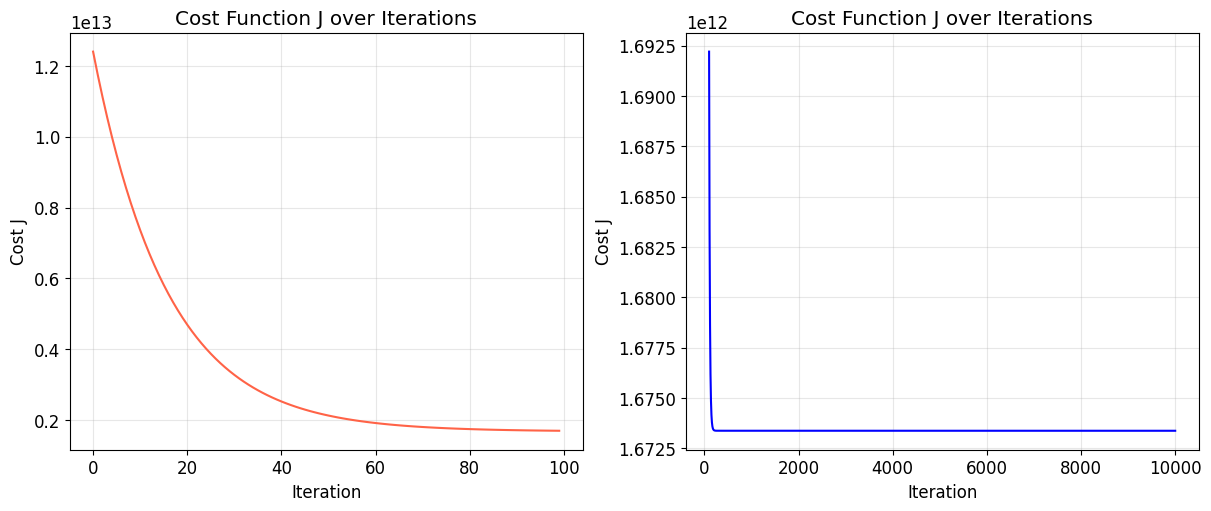

In [39]:
fig, (ax1, ax2) = plt.subplots(1, 2, constrained_layout=True, figsize=(12, 5))

ax1.plot(J_history[:100], color='tomato')
ax1.set_title('Cost Function J over Iterations')
ax1.set_ylabel('Cost J')
ax1.set_xlabel('Iteration')
ax1.grid(True, alpha=0.3)

ax2.plot(np.arange(100, len(J_history)), J_history[100:], color='blue')
ax2.set_title('Cost Function J over Iterations')
ax2.set_ylabel('Cost J')
ax2.set_xlabel('Iteration')
ax2.grid(True, alpha=0.3)
plt.show()

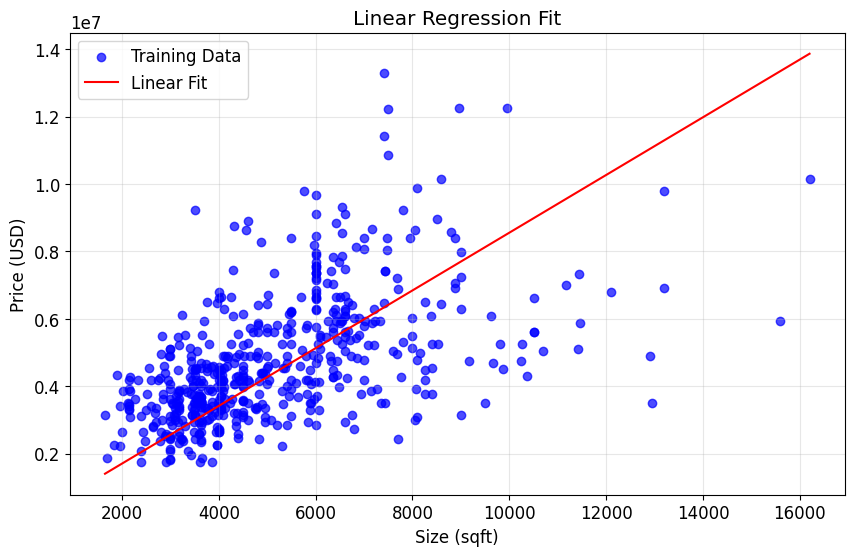

In [40]:
x_line = np.linspace(x_train.min(), x_train.max(), 100)
y_line = w_final * x_line + b_final

plt.scatter(x_train, y_train, c='blue', alpha=0.7, label='Training Data')
plt.plot(x_line, y_line, color='red', label='Linear Fit')
plt.xlabel('Size (sqft)')
plt.ylabel('Price (USD)')
plt.title('Linear Regression Fit')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [41]:
print("Predictions:")
for size in [500, 1000, 1500, 2000, 15000]:
    price_pred = w_final * size + b_final
    print(f"Size: {size} sqft -> Predicted Price: ${price_pred:,.2f}")

Predictions:
Size: 500 sqft -> Predicted Price: $427,858.40
Size: 1000 sqft -> Predicted Price: $855,713.07
Size: 1500 sqft -> Predicted Price: $1,283,567.74
Size: 2000 sqft -> Predicted Price: $1,711,422.41
Size: 15000 sqft -> Predicted Price: $12,835,643.77


In [42]:
from sklearn.linear_model import LinearRegression
import numpy as np

lr = LinearRegression()
lr.fit(x_train.reshape(-1, 1), y_train)

print("=== Comparison ===")
print(f"Your    w: {w_final:.4f}")
print(f"sklearn w: {lr.coef_[0]:.4f}")
print(f"Your    b: {b_final:.4f}")
print(f"sklearn b: {lr.intercept_:.4f}")

# Prediction at mean — should match actual mean price
pred_at_mean = w_final * x_train.mean() + b_final
print(f"\nPrediction at avg size : ${pred_at_mean:,.2f}")
print(f"Actual avg price       : ${y_train.mean():,.2f}")
print(f"Difference             : ${abs(pred_at_mean - y_train.mean()):,.2f}")

=== Comparison ===
Your    w: 855.7093
sklearn w: 461.9749
Your    b: 3.7347
sklearn b: 2387308.4824

Prediction at avg size : $4,407,370.00
Actual avg price       : $4,766,729.25
Difference             : $359,359.25
